In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy.stats import ttest_ind
import pingouin as pg
from statsmodels.multivariate.manova import MANOVA
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../Survey Results/results-survey-final-cleaned2.csv", delimiter=";")
df.rename(columns={df.columns[13]: 'group_number'}, inplace=True)

In [3]:
mapping = {
    1: ('left', 'low', 'human'),
    2: ('left', 'low', 'LLM'),
    3: ('left', 'low', 'control'),
    4: ('left', 'medium', 'human'),
    5: ('left', 'medium', 'LLM'),
    6: ('left', 'medium', 'control'),
    7: ('left', 'high', 'human'),
    8: ('left', 'high', 'LLM'),
    9: ('left', 'high', 'control'),

    10: ('center', 'low', 'human'),
    11: ('center', 'low', 'LLM'),
    12: ('center', 'low', 'control'),
    13: ('center', 'medium', 'human'),
    14: ('center', 'medium', 'LLM'),
    15: ('center', 'medium', 'control'),
    16: ('center', 'high', 'human'),
    17: ('center', 'high', 'LLM'),
    18: ('center', 'high', 'control'),

    19: ('right', 'low', 'human'),
    20: ('right', 'low', 'LLM'),
    21: ('right', 'low', 'control'),
    22: ('right', 'medium', 'human'),
    23: ('right', 'medium', 'LLM'),
    24: ('right', 'medium', 'control'),
    25: ('right', 'high', 'human'),
    26: ('right', 'high', 'LLM'),
    27: ('right', 'high', 'control'),

}

# Apply the mapping to create new columns
df[['article_orientation', 'article_bias_level', 'explanation_type']] = df['group_number'].map(mapping).apply(pd.Series)

In [4]:
df = df.rename(columns={
    "After reading the short text after the article, please tell us what you think about the following sentence: In my opinion, this article is biased.": "bias_t2",
    "Please tell us what you think about the following sentence: In my opinion, this article is biased.": "bias_t1",
    "Do you consider yourself to be liberal, conservative or somewhere in between?   [Political Orientation|Liberal|Conservative]": "Participant_Political_Lean",
    "The explanation was useful. [agree|disagree]": "Usefulness",
    "The explanation was complete. [agree|disagree]": "Completeness"
})

In [5]:
# UEQ Score
# Step 1: Reverse-code the negatively-keyed items
df["valuable_rc"] = -1 * df["The explanation was… [valuable|inferior]"]
df["good_rc"] = -1 * df["The explanation was… [good|bad]"]
df["clear_rc"] = -1 * df["The explanation was… [clear|confusing]"]

# Step 2: List of correctly-coded items (original or reversed)
ueq_items = [
    "The explanation was… [not understandable|understandable]",
    "valuable_rc",
    "The explanation was… [obstructive|supportive]",
    "good_rc",
    "The explanation was… [complicated|easy]",
    "clear_rc"
]

# Step 3: Compute the mean UEQ score per participant
df["UEQ"] = df[ueq_items].mean(axis=1)
relevant_columns = [
    'article_orientation',
    'article_bias_level',
    'explanation_type',
    'bias_t1',
    'bias_t2',
    'Participant_Political_Lean',
    'Usefulness',
    'Completeness',
    'UEQ'
]

df_relevant = df[relevant_columns].copy()

In [6]:
# Remove any zero-width spaces (or other invisible characters)
df_relevant['bias_t1'] = df_relevant['bias_t1'].str.replace(r'\u200b', '', regex=True)
df_relevant['bias_t2'] = df_relevant['bias_t2'].str.replace(r'\u200b', '', regex=True)

# Now you can safely strip any remaining whitespace and map the values
df_relevant['bias_t1'] = df_relevant['bias_t1'].str.strip()
df_relevant['bias_t2'] = df_relevant['bias_t2'].str.strip()
bias_scale = {
    "Strongly disagree": -3,
    "Disagree": -2,
    "Somewhat disagree": -1,
    "Somewhat agree": 1,
    "Agree": 2,
    "Strongly agree": 3
}

# Map responses in bias_t1 and bias_t2 to numeric values
df_relevant['bias_t1_num'] = df_relevant['bias_t1'].map(bias_scale)
df_relevant['bias_t2_num'] = df_relevant['bias_t2'].map(bias_scale)

# Calculate the change in perceived bias
df_relevant['BiasChange'] = df_relevant['bias_t2_num'] - df_relevant['bias_t1_num']

Mean bias change: 0.3499005964214712
Median bias change: 0.0
Standard deviation: 1.6462062477161103
Count of positive changes: 176
Count of negative changes: 94
Count of zero changes: 233


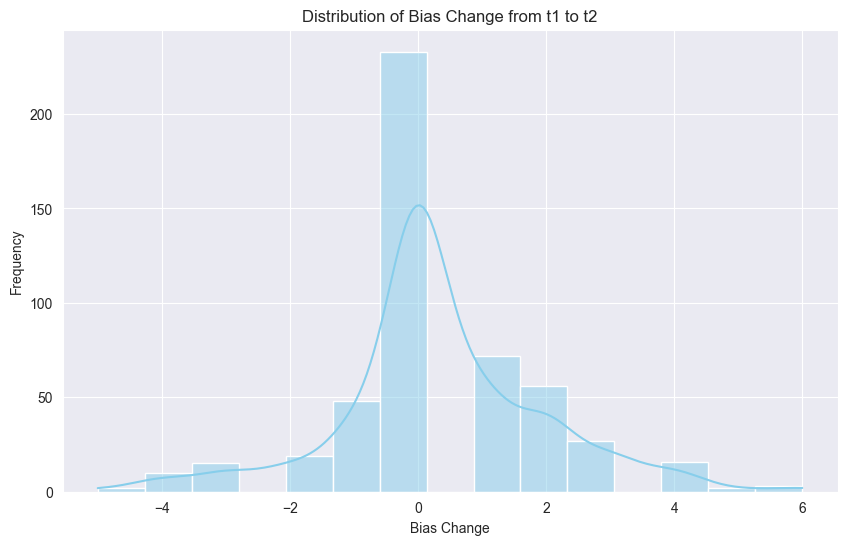

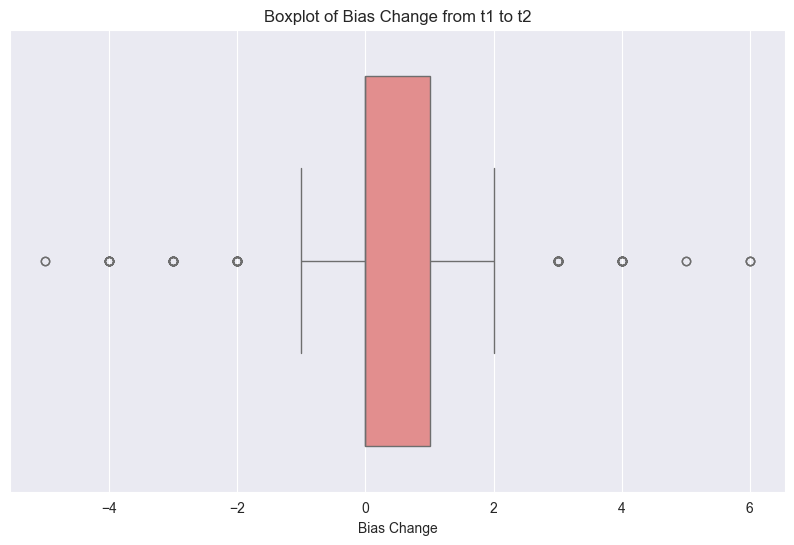

In [7]:
#General bias change analysis
mean_bias_change = df_relevant['BiasChange'].mean()
median_bias_change = df_relevant['BiasChange'].median()
std_bias_change = df_relevant['BiasChange'].std()
count_positive = len(df_relevant[df_relevant['BiasChange'] > 0])
count_negative = len(df_relevant[df_relevant['BiasChange'] < 0])
count_zero = len(df_relevant[df_relevant['BiasChange'] == 0])

print(f"Mean bias change: {mean_bias_change}")
print(f"Median bias change: {median_bias_change}")
print(f"Standard deviation: {std_bias_change}")
print(f"Count of positive changes: {count_positive}")
print(f"Count of negative changes: {count_negative}")
print(f"Count of zero changes: {count_zero}")

# 2. Visualization
plt.figure(figsize=(10, 6))

# Histogram of bias change
sns.histplot(df_relevant['BiasChange'], kde=True, bins=15, color='skyblue')
plt.title('Distribution of Bias Change from t1 to t2')
plt.xlabel('Bias Change')
plt.ylabel('Frequency')

plt.show()

# Boxplot for visualizing the spread
plt.figure(figsize=(10, 6))
sns.boxplot(x=df_relevant['BiasChange'], color='lightcoral')
plt.title('Boxplot of Bias Change from t1 to t2')
plt.xlabel('Bias Change')

plt.show()

In [8]:
df['explanation_type'] = df['explanation_type'].astype('category')
df['article_bias_level'] = df['article_bias_level'].astype('category')

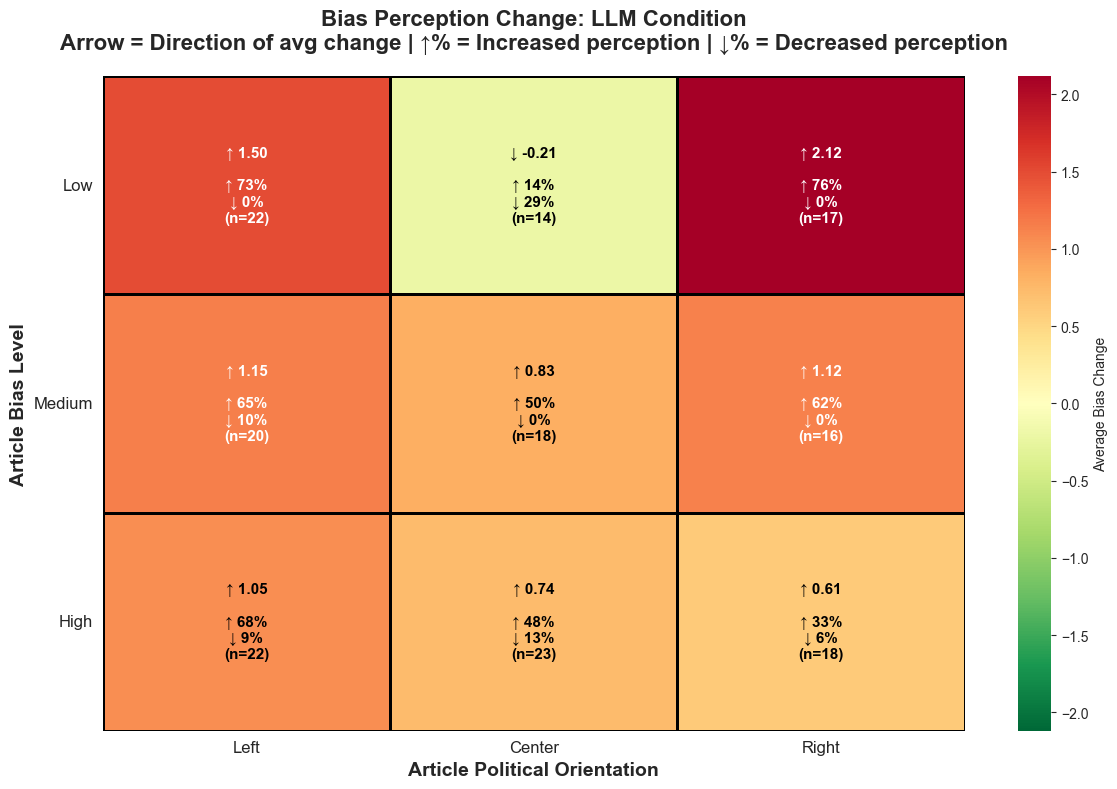

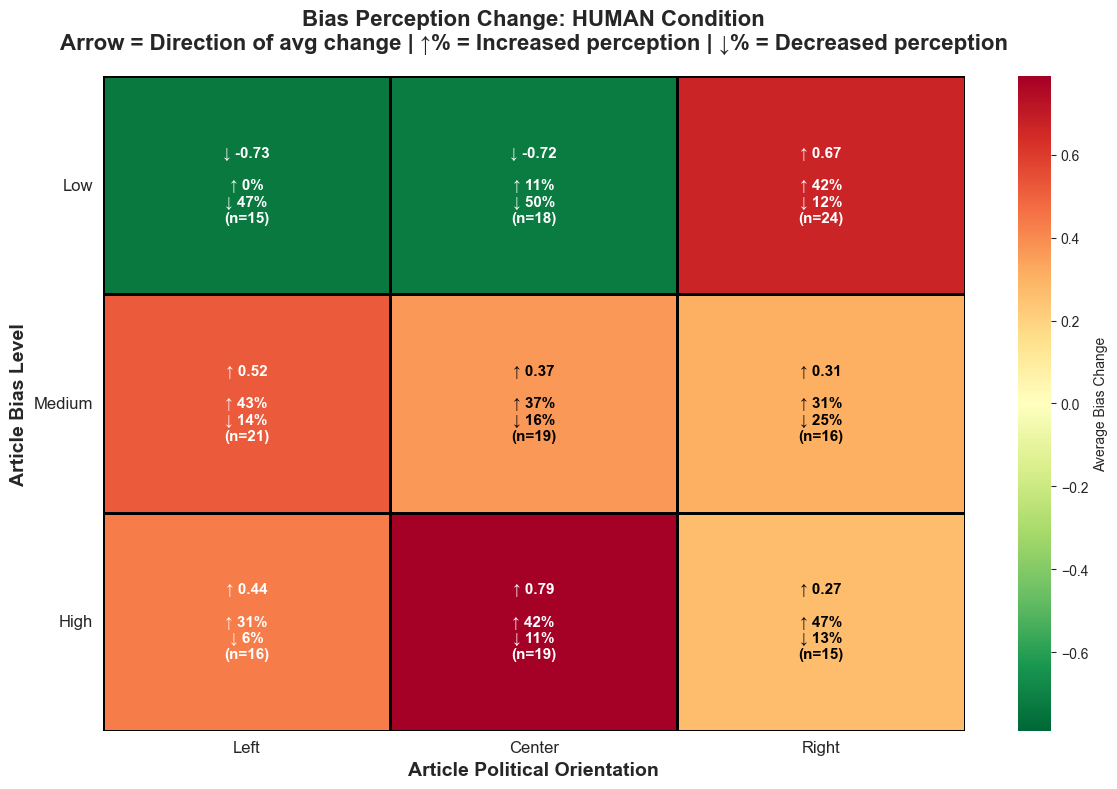

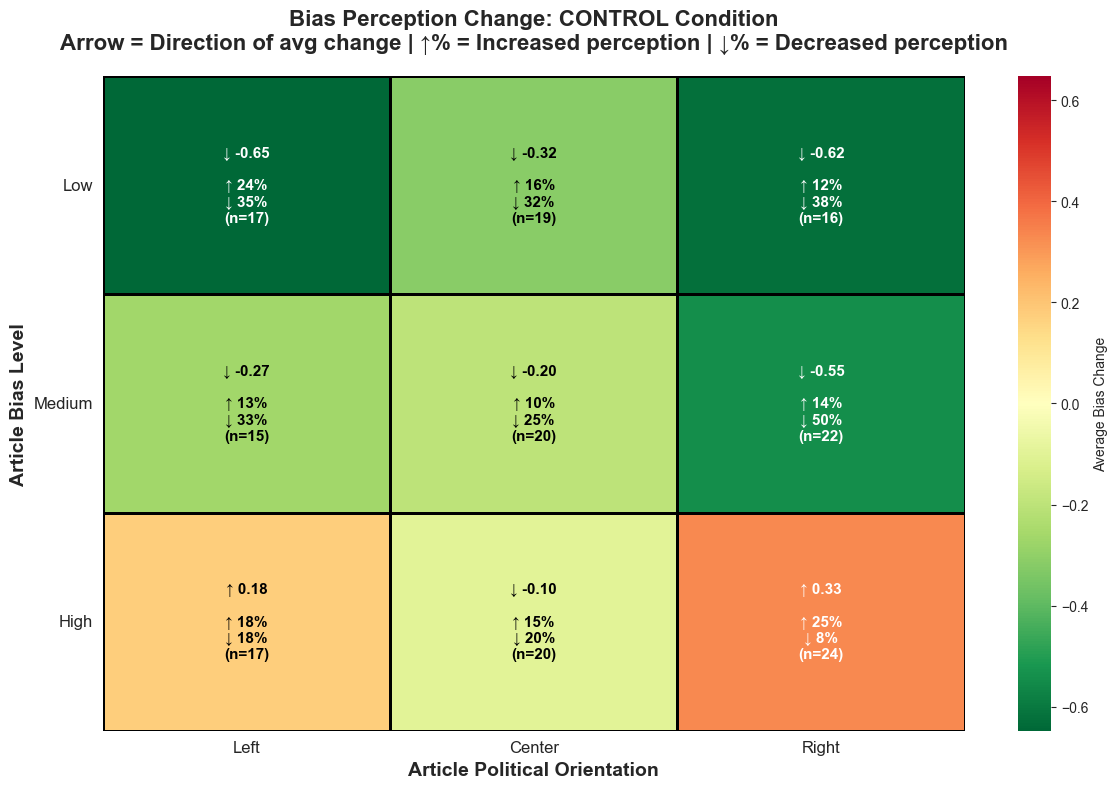


Detailed Summary by Condition:

LLM Condition:
--------------------------------------------------------------------------------
orientation bias_level  avg_change  pct_increased  pct_decreased  n_total
       left        low        1.50           72.7            0.0       22
       left     medium        1.15           65.0           10.0       20
       left       high        1.05           68.2            9.1       22
     center        low       -0.21           14.3           28.6       14
     center     medium        0.83           50.0            0.0       18
     center       high        0.74           47.8           13.0       23
      right        low        2.12           76.5            0.0       17
      right     medium        1.12           62.5            0.0       16
      right       high        0.61           33.3            5.6       18


HUMAN Condition:
--------------------------------------------------------------------------------
orientation bias_level  avg_cha

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming df_relevant is already created from your script
# This code continues from where your script left off

def create_bias_change_summary(df_relevant, explanation_type):
    """
    Create a summary table for a specific explanation type showing:
    - Average bias change
    - Percentage of participants with increased bias perception
    - Percentage of participants with decreased bias perception
    """
    # Filter for the specific explanation type
    df_filtered = df_relevant[df_relevant['explanation_type'] == explanation_type].copy()

    # Group by article_orientation and article_bias_level
    summary_data = []

    for orientation in ['left', 'center', 'right']:
        for bias_level in ['low', 'medium', 'high']:
            # Filter for this specific group
            group_data = df_filtered[
                (df_filtered['article_orientation'] == orientation) &
                (df_filtered['article_bias_level'] == bias_level)
                ]

            if len(group_data) > 0:
                # Calculate metrics
                avg_change = group_data['BiasChange'].mean()
                n_total = len(group_data)
                n_increased = len(group_data[group_data['BiasChange'] > 0])
                n_decreased = len(group_data[group_data['BiasChange'] < 0])
                pct_increased = (n_increased / n_total) * 100
                pct_decreased = (n_decreased / n_total) * 100

                summary_data.append({
                    'orientation': orientation,
                    'bias_level': bias_level,
                    'avg_change': avg_change,
                    'pct_increased': pct_increased,
                    'pct_decreased': pct_decreased,
                    'n_total': n_total
                })

    return pd.DataFrame(summary_data)

def plot_bias_change_heatmap(df_relevant, explanation_type):
    """
    Create a heatmap showing bias change with annotations for each cell
    """
    summary = create_bias_change_summary(df_relevant, explanation_type)

    # Create pivot table for average bias change
    pivot_avg = summary.pivot(index='bias_level', columns='orientation', values='avg_change')

    # Reorder to match intuitive layout
    pivot_avg = pivot_avg.reindex(['low', 'medium', 'high'])
    pivot_avg = pivot_avg[['left', 'center', 'right']]

    # Create the plot
    fig, ax = plt.subplots(figsize=(12, 8))

    # Create heatmap with diverging colormap centered at 0
    vmax = max(abs(pivot_avg.min().min()), abs(pivot_avg.max().max()))
    sns.heatmap(pivot_avg, annot=False, fmt='.2f', cmap='RdYlGn_r',
                center=0, vmin=-vmax, vmax=vmax,
                cbar_kws={'label': 'Average Bias Change'},
                linewidths=2, linecolor='black', ax=ax)

    # Add custom annotations with detailed information
    for i, bias_level in enumerate(['low', 'medium', 'high']):
        for j, orientation in enumerate(['left', 'center', 'right']):
            # Get the data for this cell
            cell_data = summary[
                (summary['bias_level'] == bias_level) &
                (summary['orientation'] == orientation)
                ]

            if not cell_data.empty:
                avg_change = cell_data['avg_change'].values[0]
                pct_increased = cell_data['pct_increased'].values[0]
                pct_decreased = cell_data['pct_decreased'].values[0]
                n_total = cell_data['n_total'].values[0]

                # Create annotation text
                direction_arrow = '↑' if avg_change > 0 else '↓' if avg_change < 0 else '→'
                text = f'{direction_arrow} {avg_change:.2f}\n\n↑ {pct_increased:.0f}%\n↓ {pct_decreased:.0f}%\n(n={n_total})'

                # Add text to cell
                ax.text(j + 0.5, i + 0.5, text,
                        ha='center', va='center',
                        fontsize=11, fontweight='bold',
                        color='black' if abs(avg_change) < vmax * 0.5 else 'white')

    # Customize labels
    ax.set_xlabel('Article Political Orientation', fontsize=14, fontweight='bold')
    ax.set_ylabel('Article Bias Level', fontsize=14, fontweight='bold')
    ax.set_title(f'Bias Perception Change: {explanation_type.upper()} Condition\n' +
                 'Arrow = Direction of avg change | ↑% = Increased perception | ↓% = Decreased perception',
                 fontsize=16, fontweight='bold', pad=20)

    # Capitalize labels
    ax.set_xticklabels([label.get_text().capitalize() for label in ax.get_xticklabels()],
                       fontsize=12)
    ax.set_yticklabels([label.get_text().capitalize() for label in ax.get_yticklabels()],
                       fontsize=12, rotation=0)

    plt.tight_layout()
    return fig

# Create the three plots
for condition in ['LLM', 'human', 'control']:
    fig = plot_bias_change_heatmap(df_relevant, condition)
    plt.savefig(f'bias_change_{condition.lower()}.png', dpi=300, bbox_inches='tight')
    plt.show()

# Optional: Create a summary table for all conditions
print("\nDetailed Summary by Condition:")
print("=" * 80)
for condition in ['LLM', 'human', 'control']:
    print(f"\n{condition.upper()} Condition:")
    print("-" * 80)
    summary = create_bias_change_summary(df_relevant, condition)
    summary_display = summary.copy()
    summary_display['avg_change'] = summary_display['avg_change'].round(2)
    summary_display['pct_increased'] = summary_display['pct_increased'].round(1)
    summary_display['pct_decreased'] = summary_display['pct_decreased'].round(1)
    print(summary_display.to_string(index=False))
    print()

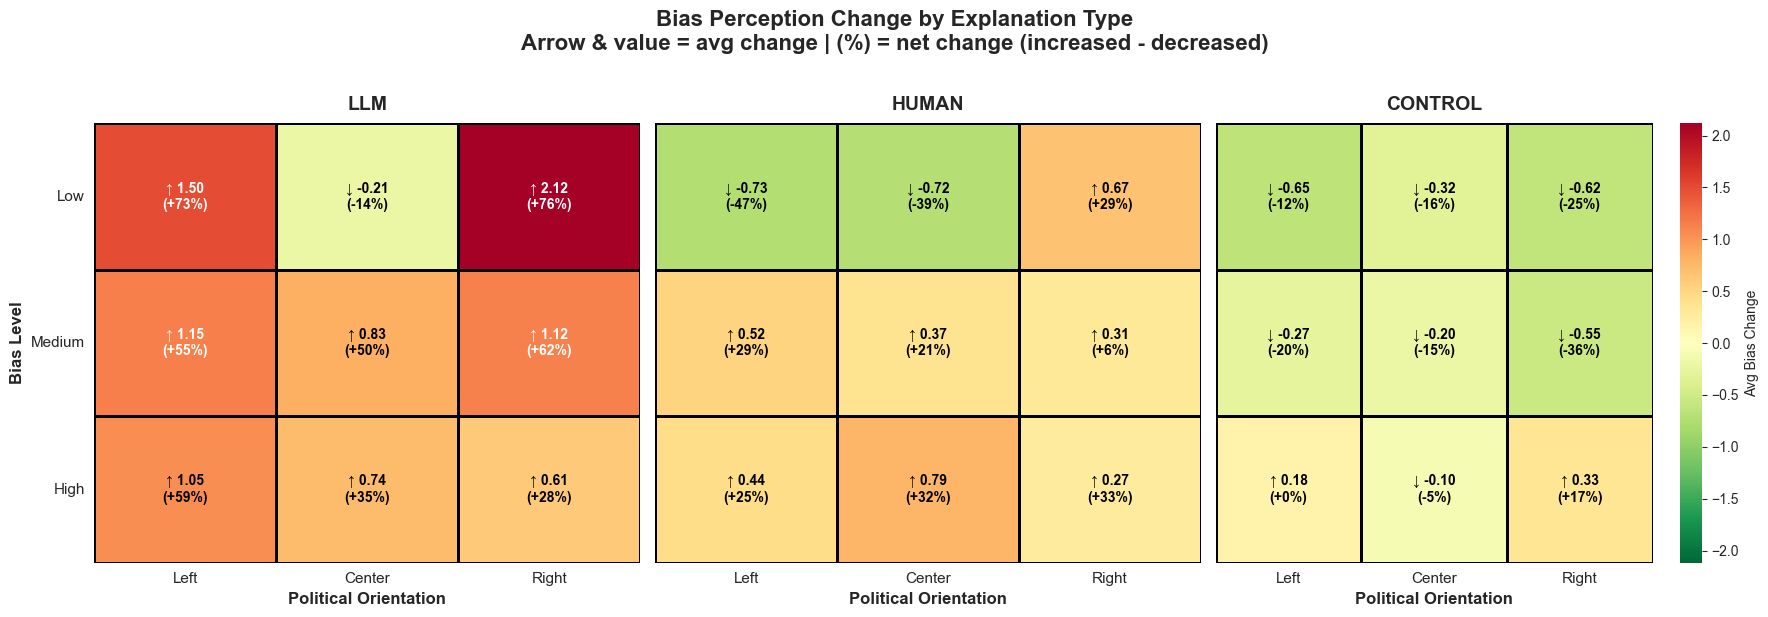


Detailed Summary by Condition:

LLM Condition:
--------------------------------------------------------------------------------
orientation bias_level  avg_change  pct_increased  pct_decreased  n_total
       left        low        1.50           72.7            0.0       22
       left     medium        1.15           65.0           10.0       20
       left       high        1.05           68.2            9.1       22
     center        low       -0.21           14.3           28.6       14
     center     medium        0.83           50.0            0.0       18
     center       high        0.74           47.8           13.0       23
      right        low        2.12           76.5            0.0       17
      right     medium        1.12           62.5            0.0       16
      right       high        0.61           33.3            5.6       18


HUMAN Condition:
--------------------------------------------------------------------------------
orientation bias_level  avg_cha

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming df_relevant is already created from your script
# This code continues from where your script left off

def create_bias_change_summary(df_relevant, explanation_type):
    """
    Create a summary table for a specific explanation type showing:
    - Average bias change
    - Percentage of participants with increased bias perception
    - Percentage of participants with decreased bias perception
    """
    # Filter for the specific explanation type
    df_filtered = df_relevant[df_relevant['explanation_type'] == explanation_type].copy()

    # Group by article_orientation and article_bias_level
    summary_data = []

    for orientation in ['left', 'center', 'right']:
        for bias_level in ['low', 'medium', 'high']:
            # Filter for this specific group
            group_data = df_filtered[
                (df_filtered['article_orientation'] == orientation) &
                (df_filtered['article_bias_level'] == bias_level)
                ]

            if len(group_data) > 0:
                # Calculate metrics
                avg_change = group_data['BiasChange'].mean()
                n_total = len(group_data)
                n_increased = len(group_data[group_data['BiasChange'] > 0])
                n_decreased = len(group_data[group_data['BiasChange'] < 0])
                pct_increased = (n_increased / n_total) * 100
                pct_decreased = (n_decreased / n_total) * 100

                summary_data.append({
                    'orientation': orientation,
                    'bias_level': bias_level,
                    'avg_change': avg_change,
                    'pct_increased': pct_increased,
                    'pct_decreased': pct_decreased,
                    'n_total': n_total
                })

    return pd.DataFrame(summary_data)

def plot_combined_bias_change(df_relevant):
    """
    Create a single figure with three subplots (one per condition) showing bias change
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # Calculate global vmax for consistent color scale
    all_summaries = []
    for condition in ['LLM', 'human', 'control']:
        all_summaries.append(create_bias_change_summary(df_relevant, condition))
    all_changes = pd.concat(all_summaries)['avg_change']
    vmax = max(abs(all_changes.min()), abs(all_changes.max()))

    for idx, (ax, condition) in enumerate(zip(axes, ['LLM', 'human', 'control'])):
        summary = create_bias_change_summary(df_relevant, condition)

        # Create pivot table for average bias change
        pivot_avg = summary.pivot(index='bias_level', columns='orientation', values='avg_change')
        pivot_avg = pivot_avg.reindex(['low', 'medium', 'high'])
        pivot_avg = pivot_avg[['left', 'center', 'right']]

        # Create heatmap
        sns.heatmap(pivot_avg, annot=False, cmap='RdYlGn_r',
                    center=0, vmin=-vmax, vmax=vmax,
                    cbar=(idx == 2),  # Only show colorbar on rightmost plot
                    cbar_kws={'label': 'Avg Bias Change'} if idx == 2 else None,
                    linewidths=2, linecolor='black', ax=ax)

        # Add annotations
        for i, bias_level in enumerate(['low', 'medium', 'high']):
            for j, orientation in enumerate(['left', 'center', 'right']):
                cell_data = summary[
                    (summary['bias_level'] == bias_level) &
                    (summary['orientation'] == orientation)
                    ]

                if not cell_data.empty:
                    avg_change = cell_data['avg_change'].values[0]
                    pct_increased = cell_data['pct_increased'].values[0]
                    pct_decreased = cell_data['pct_decreased'].values[0]

                    # Simplified annotation: arrow, value, and net direction percentage
                    direction_arrow = '↑' if avg_change > 0 else '↓' if avg_change < 0 else '→'
                    net_pct = pct_increased - pct_decreased
                    text = f'{direction_arrow} {avg_change:.2f}\n({net_pct:+.0f}%)'

                    color = 'black' if abs(avg_change) < vmax * 0.5 else 'white'
                    ax.text(j + 0.5, i + 0.5, text,
                            ha='center', va='center',
                            fontsize=10, fontweight='bold', color=color)

        # Customize labels
        ax.set_title(f'{condition.upper()}', fontsize=14, fontweight='bold', pad=10)

        if idx == 0:  # Only leftmost plot shows y-axis label
            ax.set_ylabel('Bias Level', fontsize=12, fontweight='bold')
            ax.set_yticklabels(['Low', 'Medium', 'High'], fontsize=11, rotation=0)
        else:
            ax.set_ylabel('')
            ax.set_yticklabels([])

        ax.set_xlabel('Political Orientation', fontsize=12, fontweight='bold')
        ax.set_xticklabels(['Left', 'Center', 'Right'], fontsize=11, rotation=0)

    # Add overall title
    fig.suptitle('Bias Perception Change by Explanation Type\n' +
                 'Arrow & value = avg change | (%) = net change (increased - decreased)',
                 fontsize=16, fontweight='bold', y=1.02)

    plt.tight_layout()
    return fig

# Create the combined plot
fig = plot_combined_bias_change(df_relevant)
plt.savefig('bias_change_combined.png', dpi=300, bbox_inches='tight')
plt.show()

# Optional: Create a summary table for all conditions
print("\nDetailed Summary by Condition:")
print("=" * 80)
for condition in ['LLM', 'human', 'control']:
    print(f"\n{condition.upper()} Condition:")
    print("-" * 80)
    summary = create_bias_change_summary(df_relevant, condition)
    summary_display = summary.copy()
    summary_display['avg_change'] = summary_display['avg_change'].round(2)
    summary_display['pct_increased'] = summary_display['pct_increased'].round(1)
    summary_display['pct_decreased'] = summary_display['pct_decreased'].round(1)
    print(summary_display.to_string(index=False))
    print()

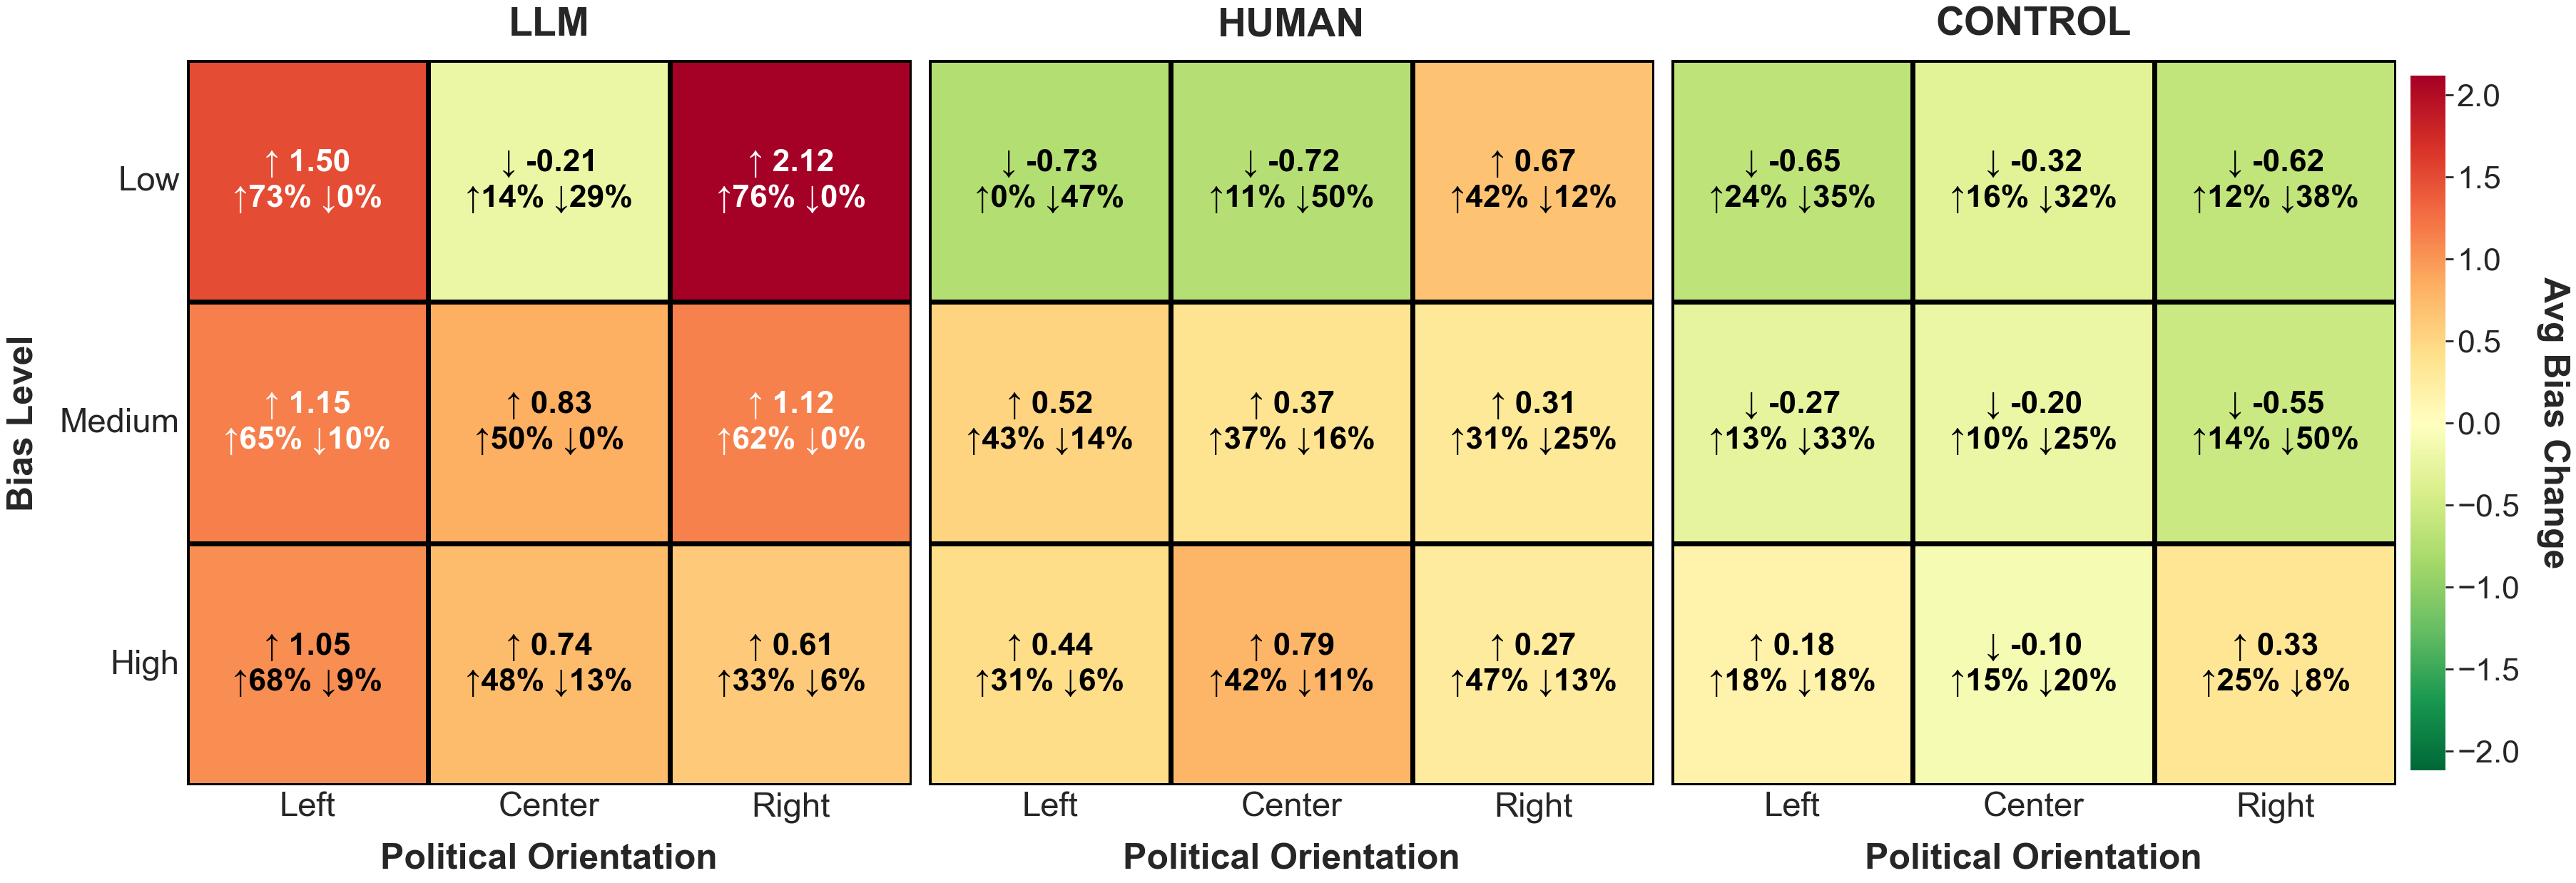


LaTeX code to include this figure:

\begin{figure*}[htbp]
    \centering
    \includegraphics[width=\textwidth]{bias_change_combined.png}
    \caption{Bias perception change across experimental conditions. Each subplot represents one explanation type condition (LLM-generated, human-generated, or control). Cells are organized by article bias level (rows) and political orientation (columns). The color intensity indicates the magnitude and direction of average bias change (red = increased perception of bias, green = decreased perception). Annotations show: directional arrow and average change value, percentage of participants with increased bias perception (↑), and percentage with decreased bias perception (↓). The color scale is consistent across all three conditions to facilitate comparison.}
    \label{fig:bias_change}
\end{figure*}


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def create_bias_change_summary(df_relevant, explanation_type):
    """
    Create a summary table for a specific explanation type showing:
    - Average bias change
    - Percentage of participants with increased bias perception
    - Percentage of participants with decreased bias perception
    """
    df_filtered = df_relevant[df_relevant['explanation_type'] == explanation_type].copy()
    summary_data = []

    for orientation in ['left', 'center', 'right']:
        for bias_level in ['low', 'medium', 'high']:
            group_data = df_filtered[
                (df_filtered['article_orientation'] == orientation) &
                (df_filtered['article_bias_level'] == bias_level)
                ]

            if len(group_data) > 0:
                avg_change = group_data['BiasChange'].mean()
                n_total = len(group_data)
                n_increased = len(group_data[group_data['BiasChange'] > 0])
                n_decreased = len(group_data[group_data['BiasChange'] < 0])
                pct_increased = (n_increased / n_total) * 100
                pct_decreased = (n_decreased / n_total) * 100

                summary_data.append({
                    'orientation': orientation,
                    'bias_level': bias_level,
                    'avg_change': avg_change,
                    'pct_increased': pct_increased,
                    'pct_decreased': pct_decreased,
                    'n_total': n_total
                })

    return pd.DataFrame(summary_data)

def plot_combined_bias_change(df_relevant):
    """
    Create a single figure with three subplots (one per condition) showing bias change
    """
    # Much larger figure size with constrained layout
    fig, axes = plt.subplots(1, 3, figsize=(36, 14), constrained_layout=True)

    # Calculate global vmax for consistent color scale
    all_summaries = []
    for condition in ['LLM', 'human', 'control']:
        all_summaries.append(create_bias_change_summary(df_relevant, condition))
    all_changes = pd.concat(all_summaries)['avg_change']
    vmax = max(abs(all_changes.min()), abs(all_changes.max()))

    for idx, (ax, condition) in enumerate(zip(axes, ['LLM', 'human', 'control'])):
        summary = create_bias_change_summary(df_relevant, condition)

        # Create pivot table for average bias change
        pivot_avg = summary.pivot(index='bias_level', columns='orientation', values='avg_change')
        pivot_avg = pivot_avg.reindex(['low', 'medium', 'high'])
        pivot_avg = pivot_avg[['left', 'center', 'right']]

        # Create heatmap - only show colorbar on rightmost plot
        # Use gridspec_kw to ensure equal subplot widths
        sns.heatmap(pivot_avg, annot=False, cmap='RdYlGn_r',
                    center=0, vmin=-vmax, vmax=vmax,
                    cbar=(idx == 2),  # Only show colorbar on rightmost plot
                    cbar_kws={'label': 'Avg Bias Change', 'shrink': 0.7, 'pad': 0.02} if idx == 2 else None,
                    linewidths=5, linecolor='black', ax=ax,
                    square=True)

        # Style colorbar for rightmost plot only
        if idx == 2:
            cbar = ax.collections[0].colorbar
            cbar.ax.tick_params(labelsize=32, width=2, length=8)
            cbar.set_label('Avg Bias Change', fontsize=36, fontweight='bold', rotation=270, labelpad=50)

        # Add annotations with much larger text
        for i, bias_level in enumerate(['low', 'medium', 'high']):
            for j, orientation in enumerate(['left', 'center', 'right']):
                cell_data = summary[
                    (summary['bias_level'] == bias_level) &
                    (summary['orientation'] == orientation)
                    ]

                if not cell_data.empty:
                    avg_change = cell_data['avg_change'].values[0]
                    pct_increased = cell_data['pct_increased'].values[0]
                    pct_decreased = cell_data['pct_decreased'].values[0]

                    direction_arrow = '↑' if avg_change > 0 else '↓' if avg_change < 0 else '→'
                    text = f'{direction_arrow} {avg_change:.2f}\n↑{pct_increased:.0f}% ↓{pct_decreased:.0f}%'

                    color = 'black' if abs(avg_change) < vmax * 0.5 else 'white'
                    ax.text(j + 0.5, i + 0.5, text,
                            ha='center', va='center',
                            fontsize=32, fontweight='bold', color=color, linespacing=1.3)

        # Customize labels with much larger fonts
        ax.set_title(f'{condition.upper()}', fontsize=40, fontweight='bold', pad=25)

        if idx == 0:
            ax.set_ylabel('Bias Level', fontsize=36, fontweight='bold', labelpad=20)
            ax.set_yticklabels(['Low', 'Medium', 'High'], fontsize=34, rotation=0)
        else:
            ax.set_ylabel('')
            ax.set_yticklabels([])

        ax.set_xlabel('Political Orientation', fontsize=36, fontweight='bold', labelpad=20)
        ax.set_xticklabels(['Left', 'Center', 'Right'], fontsize=34, rotation=0)

    # Add overall title with much larger font
    #fig.suptitle('Bias Perception Change by Explanation Type\n' +
     #            'Arrow & value = avg change | ↑% = increased perception | ↓% = decreased perception',
      #           fontsize=34, fontweight='bold', y=0.98)

    return fig

# Create the combined plot
fig = plot_combined_bias_change(df_relevant)
plt.savefig('bias_change_combined.png', dpi=300, bbox_inches='tight')
plt.show()

# Print LaTeX code for including the figure
print("\n" + "="*80)
print("LaTeX code to include this figure:")
print("="*80)
print("""
\\begin{figure*}[htbp]
    \\centering
    \\includegraphics[width=\\textwidth]{bias_change_combined.png}
    \\caption{Bias perception change across experimental conditions. Each subplot represents one explanation type condition (LLM-generated, human-generated, or control). Cells are organized by article bias level (rows) and political orientation (columns). The color intensity indicates the magnitude and direction of average bias change (red = increased perception of bias, green = decreased perception). Annotations show: directional arrow and average change value, percentage of participants with increased bias perception (↑), and percentage with decreased bias perception (↓). The color scale is consistent across all three conditions to facilitate comparison.}
    \\label{fig:bias_change}
\\end{figure*}
""")